# Manual iterative LSI implementation

In [24]:
here::i_am("blood_trajectory/manual_iterativeLSI.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))


# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [25]:
args <- list()
# in vivo
io$atlas.basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'
args$sce_atlas <-file.path(io$atlas.basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
args$metadataRNA_atlas <- file.path(io$atlas.basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC_atlas <- file.path(io$atlas.basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$celltype_label <- "celltype"

args$sample <- c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')

# LSI
args$ntop = 55000
args$ndims = 25

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Anterior_Primitive_Streak",
                    "Nascent_mesoderm",
                    "Intermediate_mesoderm", 
                    "Pharyngeal_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3",
                    "PGC",
                    "Surface_ectoderm")

# I/O
args$outdir = file.path(io$basedir, 'results/epiblast_blood/atac/')
dir.create(args$outdir, showWarnings=F, recursive=T)

In [26]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"

### In Vivo

In [7]:
##########################
## Load sample metadata ##
##########################

metadata_atlas <- fread(args$metadataRNA_atlas) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC_atlas)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

stopifnot(args$celltype_label%in%colnames(metadata_atlas))
metadata_atlas <- metadata_atlas   %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample]

table(metadata_atlas$celltype)

#############################
## Load ATAC accessibility ##
#############################
  
sce = readRDS(args$sce_atlas)
sce = sce[,metadata_atlas$cell]
sce = as(sce, 'SingleCellExperiment')

# Filter regions accessibile in 5% of cells
nCells = 0.05 * nrow(metadata_atlas)
region_counts = rowSums(assay(sce, 'PeakMatrix')>0)
keep_regions = region_counts[region_counts>nCells]
sce = sce[names(keep_regions), ]

assay(sce, 'counts') = assay(sce, 'PeakMatrix')
assay(sce, 'PeakMatrix') = NULL

colData(sce) <- metadata_atlas %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce),] %>% DataFrame()


                      Epiblast               Primitive_Streak 
                           984                            542 
     Anterior_Primitive_Streak               Nascent_mesoderm 
                           138                           1327 
         Intermediate_mesoderm            Pharyngeal_mesoderm 
                           808                           1710 
                  ExE_mesoderm                 Mixed_mesoderm 
                          1173                            265 
                     Allantois                     Mesenchyme 
                           653                           3123 
Haematoendothelial_progenitors                    Endothelium 
                           913                            666 
           Blood_progenitors_1            Blood_progenitors_2 
                           230                            565 
                    Erythroid1                     Erythroid2 
                          1119                        

In [8]:
atac.counts = counts(sce)

In [10]:
###################
## Iterative LSI ##
###################

## First round of LSI on just top accessible features

# Extract top accessible features
top_atlas = rowMeans(counts(sce))
top_atlas = top_atlas[order(-top_atlas)]

# get overlap of top 40k features
top = head(top_atlas, args$ntop)

# TFIDF normalisation
atac_tfidf.mtx <- tfidf(atac.counts[top,], method=1, scale.factor=1e4)

# LSI
svd <- irlba::irlba(atac_tfidf.mtx, args$ndims, args$ndims)
svdDiag <- matrix(0, nrow=args$ndims, ncol=args$ndims)
diag(svdDiag) <- svd$d
svd.mtx <- t(svdDiag %*% t(svd$v))
rownames(svd.mtx) <- colnames(sce)
colnames(svd.mtx) <- paste0("LSI",seq_len(ncol(svd.mtx)))

rm(svd,svdDiag)

Warning message in tfidf(atac.counts[top, ], method = 1, scale.factor = 10000):
“Some cells contain 0 total counts”


In [11]:
summary(rownames(svd.mtx) == colnames(sce))

   Mode    TRUE 
logical   17986 

In [12]:
# clustering in Seurat
library(Seurat)

# Create object
seurat = CreateSeuratObject(
  counts = counts(sce))
# Add LSI
seurat[['LSI']] = CreateDimReducObject(embeddings = svd.mtx, key = "LSI_", assay = DefaultAssay(seurat))
# Find clusters
seurat <- FindNeighbors(seurat, dims = 1:args$ndims, reduction = 'LSI')
seurat <- FindClusters(seurat, resolution = 0.3, reduction = 'LSI')
clusters = seurat@meta.data$seurat_clusters

# Find variable features across clusters 
sce_pb = aggregateAcrossCells(sce, id=clusters, BPPARAM = BPPARAM, statistics='mean')
region_vars = rowVars(counts(sce_pb))
names(region_vars) = rownames(sce_pb)


## second round of LSI on top variable features

region_vars = region_vars[order(-region_vars)]
# get overlap of top 40k features
top = names(head(region_vars, args$ntop))

# TFIDF normalisation
atac_tfidf.mtx <- tfidf(atac.counts[top,], method=1, scale.factor=1e4)

# LSI
svd <- irlba::irlba(atac_tfidf.mtx, args$ndims, args$ndims)
svdDiag <- matrix(0, nrow=args$ndims, ncol=args$ndims)
diag(svdDiag) <- svd$d
svd.mtx <- t(svdDiag %*% t(svd$v))
rownames(svd.mtx) <- colnames(sce)
colnames(svd.mtx) <- paste0("LSI",seq_len(ncol(svd.mtx)))

rm(svd,svdDiag)

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”
Attaching SeuratObject


Attaching package: ‘Seurat’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays


Computing nearest neighbor graph

Computing SNN

Warning message:
“The following arguments are not used: reduction”
Warning message:
“The following arguments are not used: reduction”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17986
Number of edges: 323483

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9027
Number of communities: 8
Elapsed time: 0 seconds


In [13]:
svd.dt = as.data.table(svd.mtx, keep.rownames=T) %>% setnames('rn', 'cell')

In [14]:
fwrite(svd.dt, sprintf("%s/LSI.txt.gz",args$outdir))

In [15]:
head(svd.dt)

cell,LSI1,LSI2,LSI3,LSI4,LSI5,LSI6,LSI7,LSI8,LSI9,⋯,LSI16,LSI17,LSI18,LSI19,LSI20,LSI21,LSI22,LSI23,LSI24,LSI25
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
E7.5_rep1#AAACAGCCATCCTGAA-1,43.43172,-9.418513,8.7559556,-5.59898345,-8.6807304,5.64716839,6.253509,-1.6404776,-2.0733543,⋯,4.77622669,-0.7168445,-4.0929928,-2.40545459,3.0580618,0.5469985,-2.09467909,1.4376694,-2.1311023,-2.4779272
E7.5_rep1#AAACAGCCATGCTATG-1,53.00335,-13.029163,15.9438411,-5.28241871,0.7234708,0.05948825,-1.670999,0.9876345,5.4923881,⋯,-1.25042203,-0.2249789,-1.6081325,0.64422040,-2.9248496,-0.5442030,0.02510472,0.0324689,-0.9472813,0.4648984
E7.5_rep1#AAACATGCAGGATAAC-1,18.26584,7.026180,0.4614735,0.04930606,-0.8348097,4.48565611,1.813588,1.9968267,1.1517900,⋯,-0.52543274,2.3774348,-0.4341098,-0.80595232,1.6339605,2.0150088,1.49999606,0.1037849,-0.6282185,-0.5175623
E7.5_rep1#AAACCGGCAACCCTAA-1,57.68750,-11.901260,15.3124732,-6.33653569,-3.2861077,0.03278077,1.294370,-0.4101102,0.7390047,⋯,0.08214293,-1.6468944,0.3025171,0.33705657,-1.7665109,1.3378240,1.46626646,2.4505039,1.1282450,3.7196228
E7.5_rep1#AAACCGGCAACCTAAT-1,50.00439,11.394419,1.4905166,-3.91934205,-4.1843966,7.02224579,-4.577761,4.2423740,-5.3732630,⋯,1.30647649,2.6745870,-1.7343745,0.26726605,2.0757473,3.8904119,2.71829733,0.7725477,-0.5410337,-0.1419384
E7.5_rep1#AAACGGATCACGCCAA-1,54.33157,-11.078531,16.8158349,-4.24699606,3.9075252,-0.23225843,-1.028670,0.8015337,6.7906240,⋯,-1.16745443,-0.3376537,-1.1635251,0.08862683,-0.1965417,0.6477108,-0.48746558,-0.1062776,-0.8799013,-0.7685820


In [16]:
######################
## Batch correction ##
######################
pca.mtx = svd.mtx
sample_metadata = as.data.table(colData(sce), keep.rownames=T) %>% setnames('rn', 'cell')

# Define stage and sample order
stopifnot(sample_metadata$cell==rownames(pca.mtx))
timepoints <- sample_metadata$stage
timepoint_order <- c('E8.75', 'E8.5', 'E8.0', 'E7.75', 'E7.5')
samples <- sample_metadata$sample
sample_order = as.data.table(table(sample_metadata$sample))[order(-N), V1] # order from most to least cells

pca_list    <- lapply(unique(timepoints), function(i){
    sub_pc   <- pca.mtx[timepoints == i, , drop = FALSE]
    sub_samp <- samples[timepoints == i]
    list     <- lapply(unique(sub_samp), function(j){ sub_pc[sub_samp == j, , drop = FALSE]})
    names(list) <- unique(sub_samp)
    return(list)
})
names(pca_list) <- unique(timepoints)

#arrange to match timepoint order
pca_list <- pca_list[order(match(names(pca_list), timepoint_order))]
pca_list <- lapply(pca_list, function(x){ x[order(match(names(x), sample_order))]})

#perform corrections within stages
correct_list <- lapply(pca_list, function(x){
if(length(x) > 1){
  return(do.call(reducedMNN, x)$corrected)
} else {
  return(x[[1]])
}
})

# perform correction over stages
pca.corrected <- reducedMNN(correct_list, merge.order=1:length(correct_list))$corrected 
colnames(pca.corrected) <- paste0("PC",1:ncol(pca.corrected))
rm(correct_list,pca_list)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [17]:
LSI.corrected = pca.corrected
colnames(LSI.corrected) = paste0('LSI', 1:dim(LSI.corrected)[2])

In [21]:
get_umap = function(ndims = args$ndims, n_neighbors = 25, min_dist=0.3, plot=FALSE){
    umap.mtx = umap(LSI.corrected[,1:ndims], 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        ggtitle('celltype') + 
        scale_colour_manual(values=opts$stage.colors) + 
        theme_void() + 
        theme(legend.position="none")
    
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

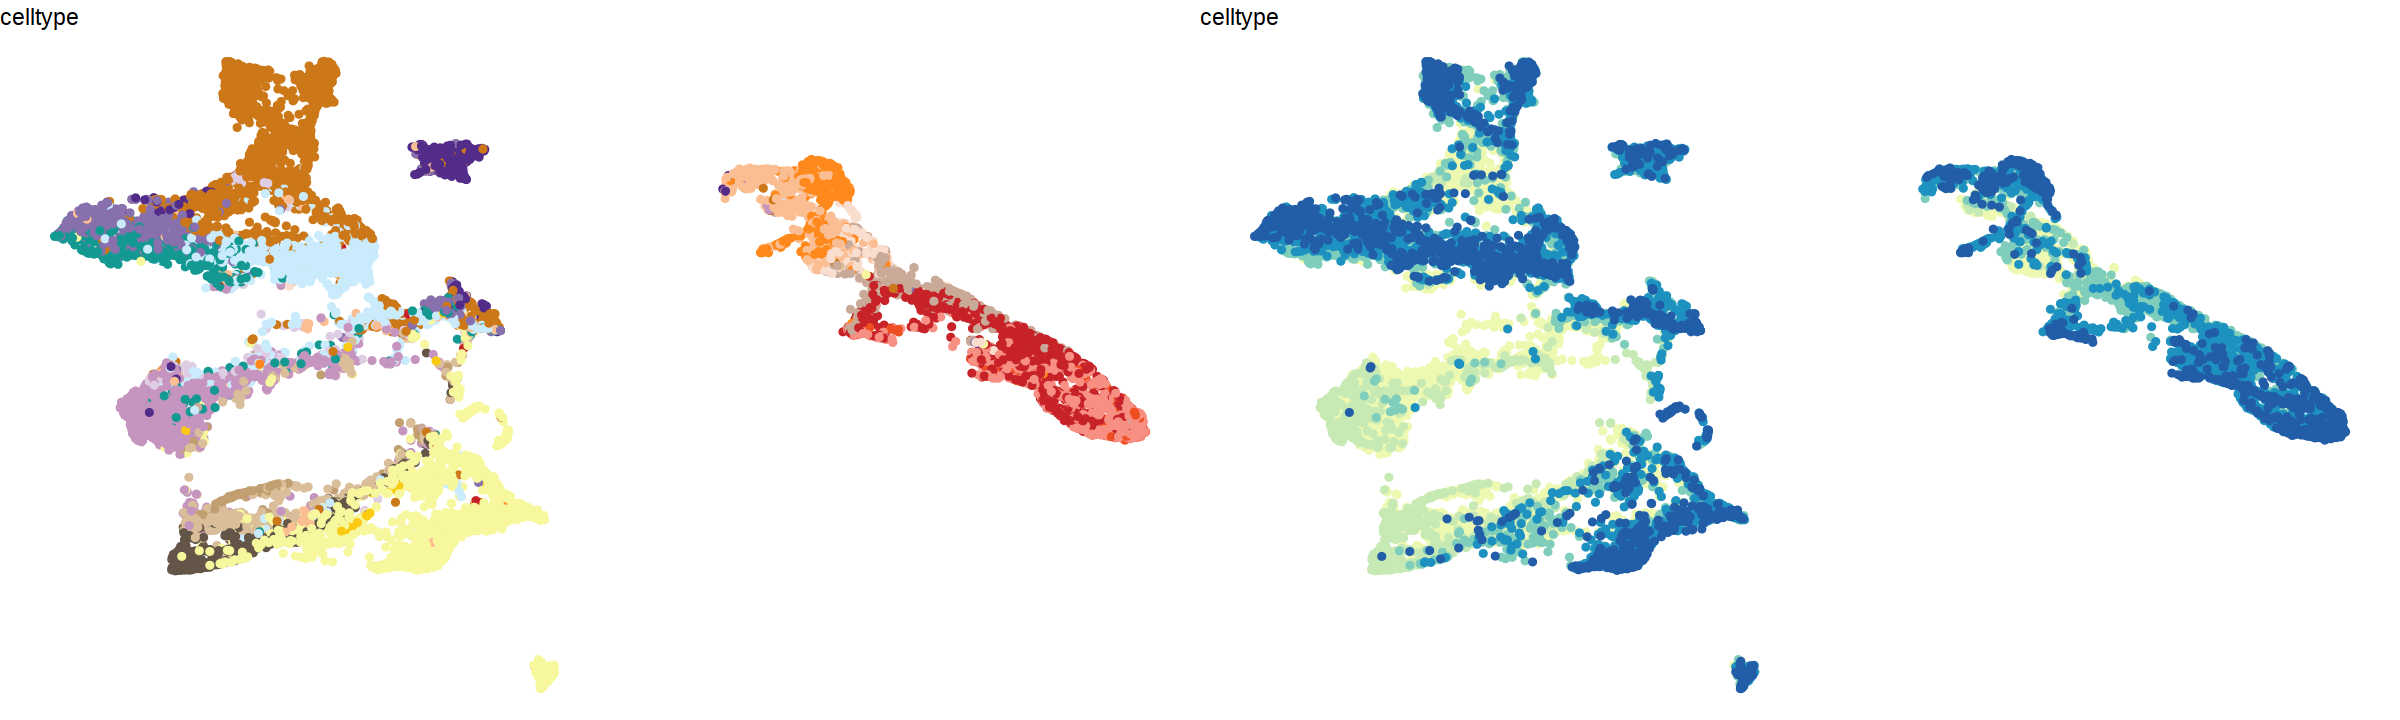

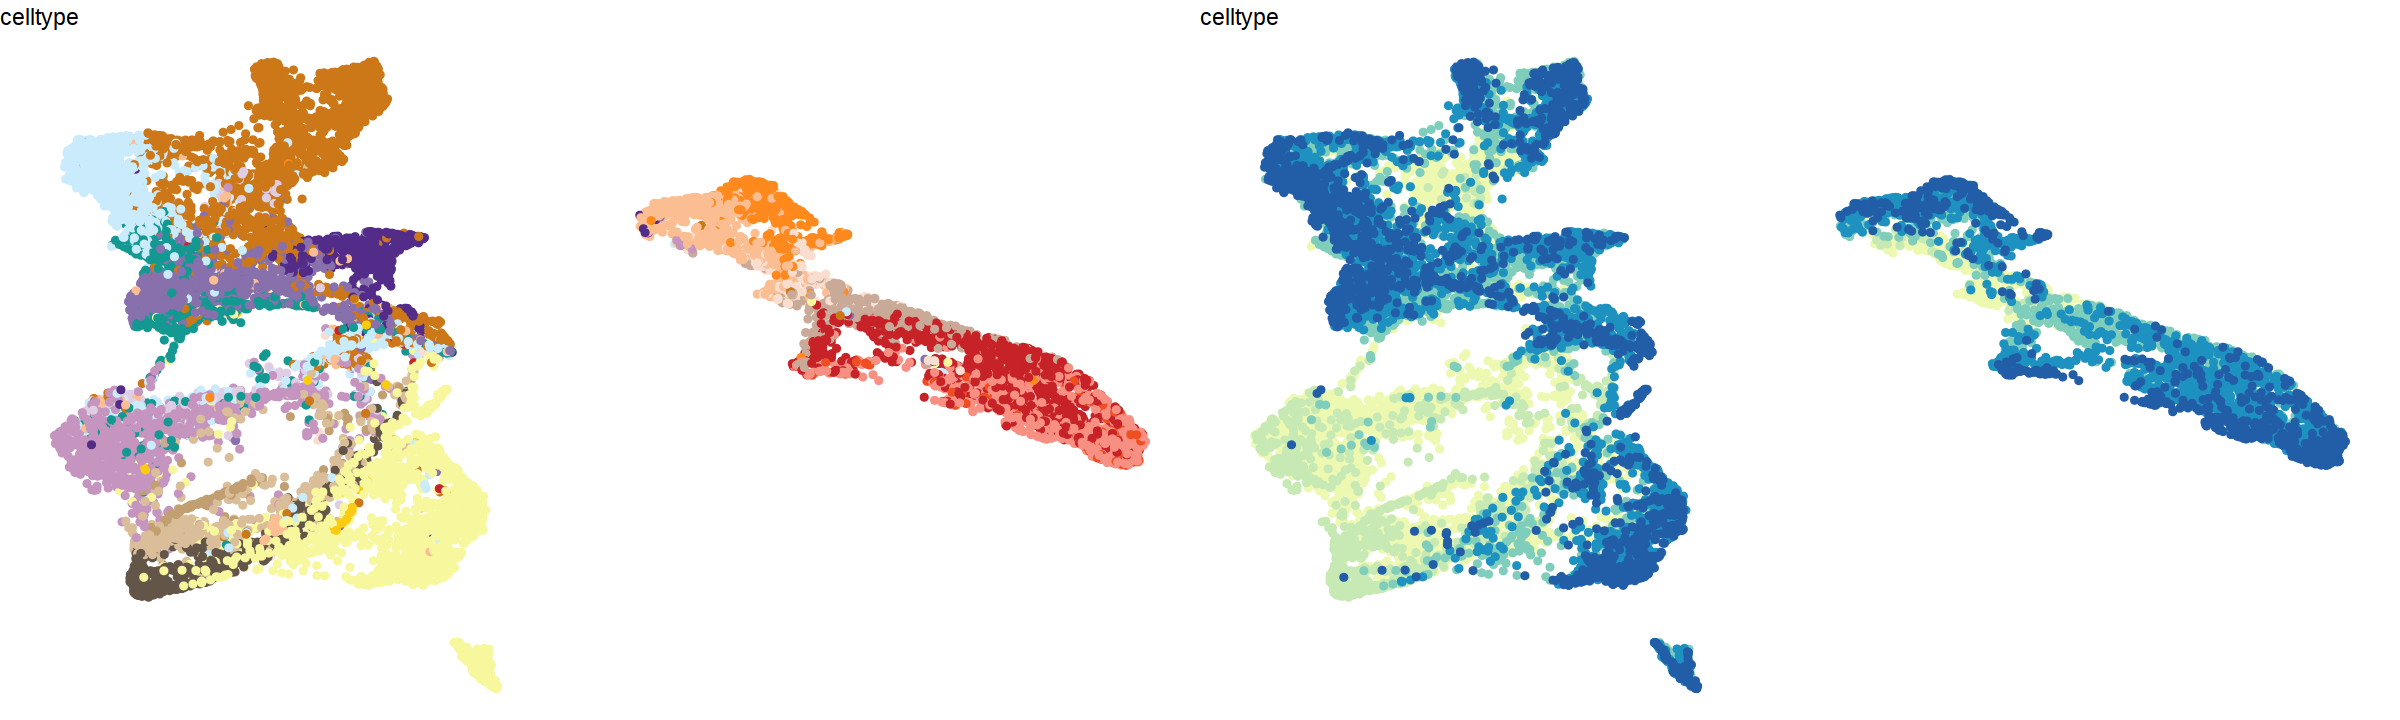

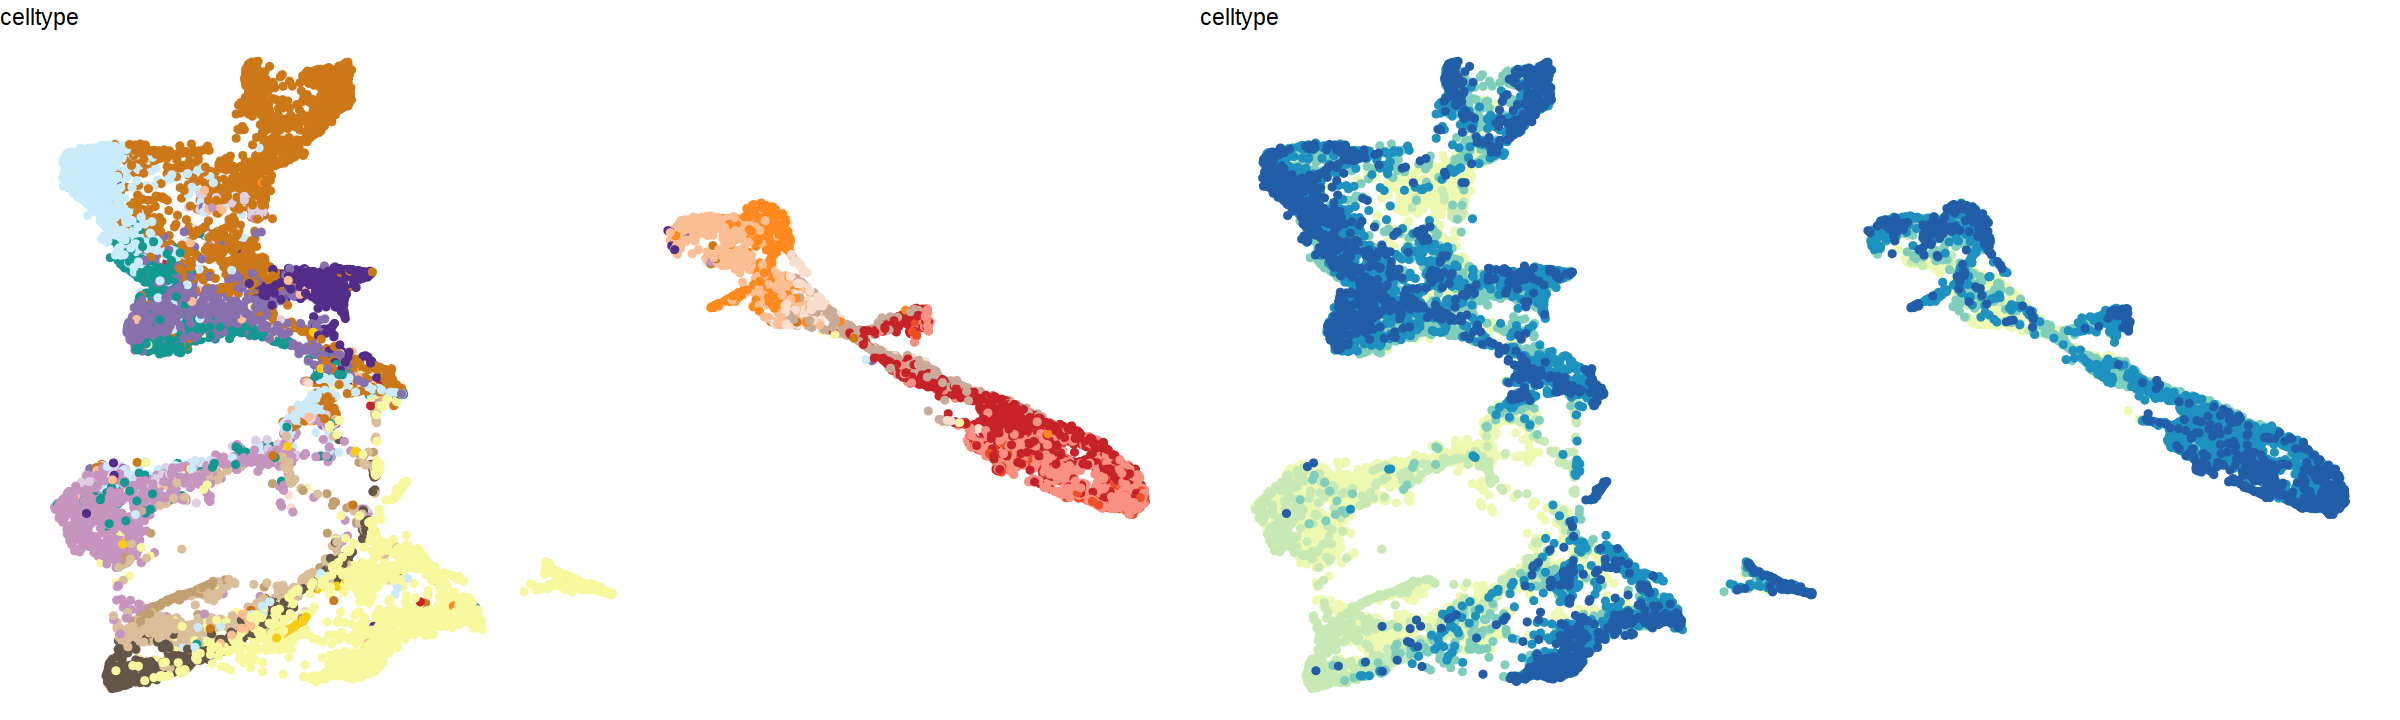

In [23]:
get_umap(n_neighbors =  20, min_dist= 0.01, plot=TRUE)
get_umap(n_neighbors =  20, min_dist= 0.1, plot=TRUE)
get_umap(n_neighbors =  25, min_dist= 0.01, plot=TRUE)

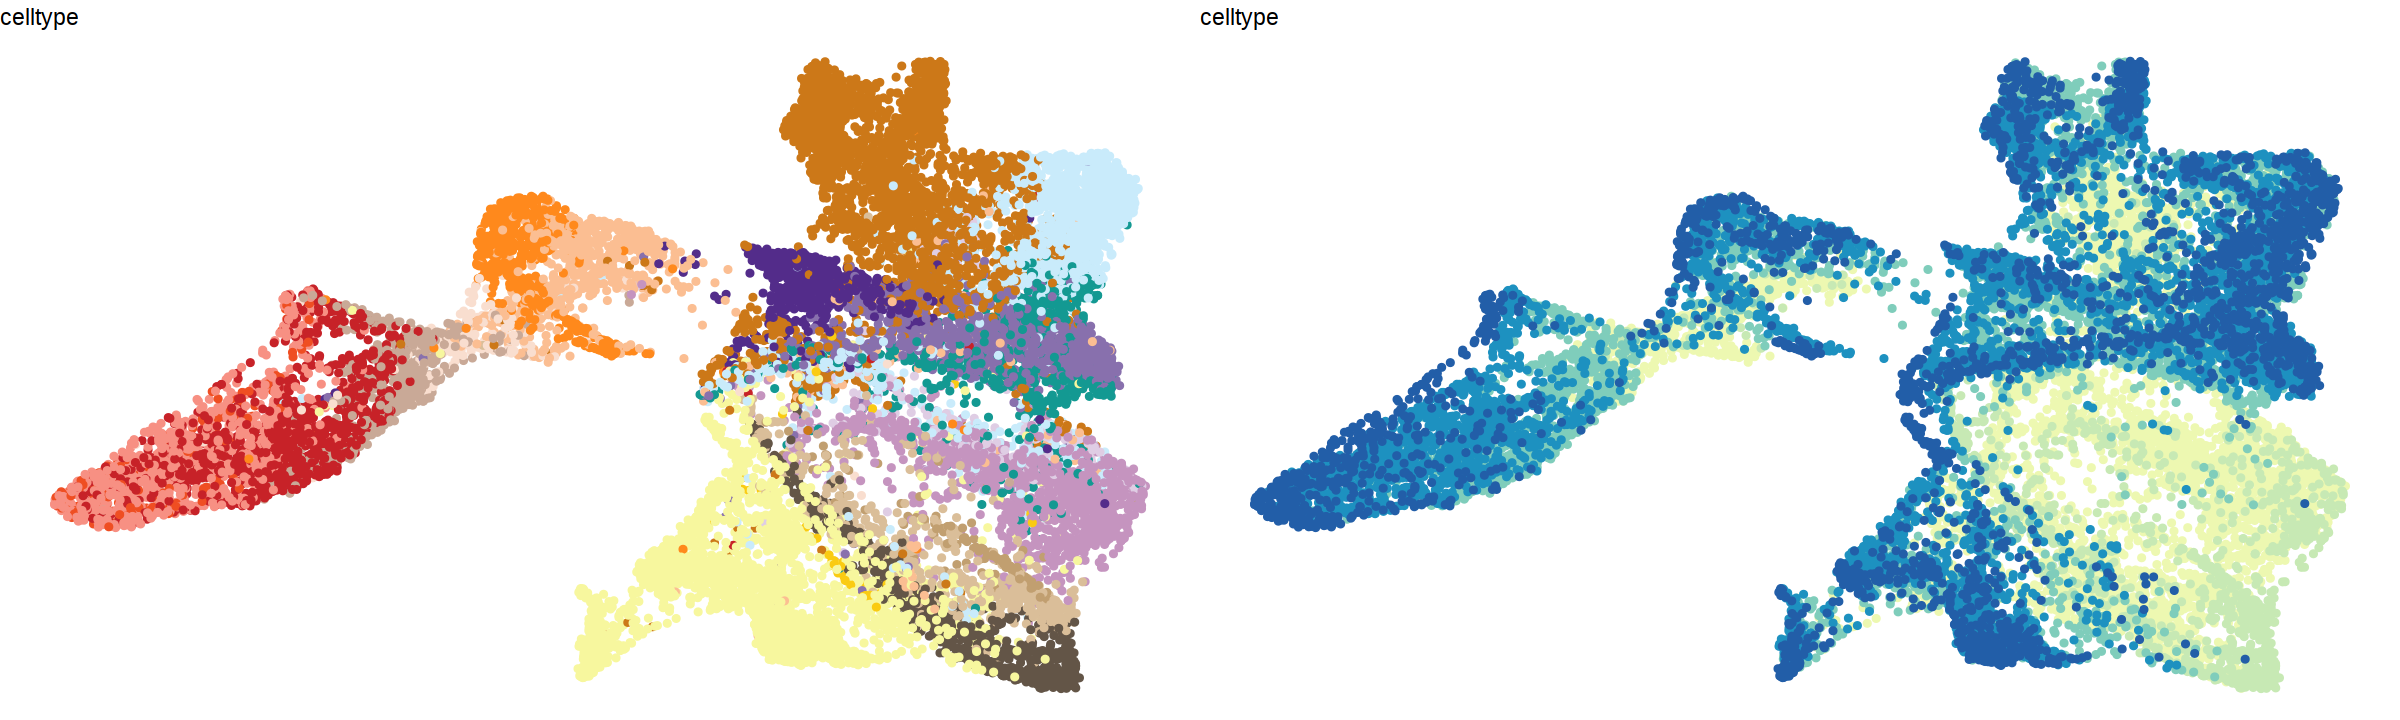

In [27]:
get_umap(n_neighbors =  30, min_dist= 0.3, plot=TRUE)

# Using ArchR code

In [42]:
head(atac.counts)

   [[ suppressing 34 column names ‘E7.5_rep1#AAACAGCCATCCTGAA-1’, ‘E7.5_rep1#AAACAGCCATGCTATG-1’, ‘E7.5_rep1#AAACATGCAGGATAAC-1’ ... ]]



6 x 17986 sparse Matrix of class "dgCMatrix"
                                                                              
chr1:3191496-3192096 . . . . . . 2 . . . . . . . . . . 2 . . . 2 . . . . . . .
chr1:3670515-3671115 3 4 . . . . . 3 . 2 . . . . . . . . . . . 2 . . . . . . .
chr1:3671511-3672111 2 2 . . . 4 3 4 1 2 . . . . 1 . . . . . . . . . . . . . .
chr1:3672237-3672837 . 3 . . . . 3 2 . 4 . . 3 . . . 4 . . . . . . . . . . . 2
chr1:4412337-4412937 . . . . . . . . . . . . . . . . . . . 2 . . . . . . . . .
chr1:4491836-4492436 . 3 . . . . . . . . . . . . . . . . . . . . . . . . . . .
                                     
chr1:3191496-3192096 . . . . . ......
chr1:3670515-3671115 2 . . . . ......
chr1:3671511-3672111 2 . . . . ......
chr1:3672237-3672837 . . . . . ......
chr1:4412337-4412937 . . . . . ......
chr1:4491836-4492436 4 . . . . ......

 .....suppressing 17952 columns in show(); maybe adjust 'options(max.print= *, width = *)'
 ..............................

In [28]:
LSI = ArchR:::.computeLSI( mat = atac.counts[top,], 
  LSIMethod = 1,
  scaleTo = 10^4,
  nDimensions = args$ndims, 
  binarize = TRUE, 
  outlierQuantiles = c(0.02, 0.98),
  seed = 1234)

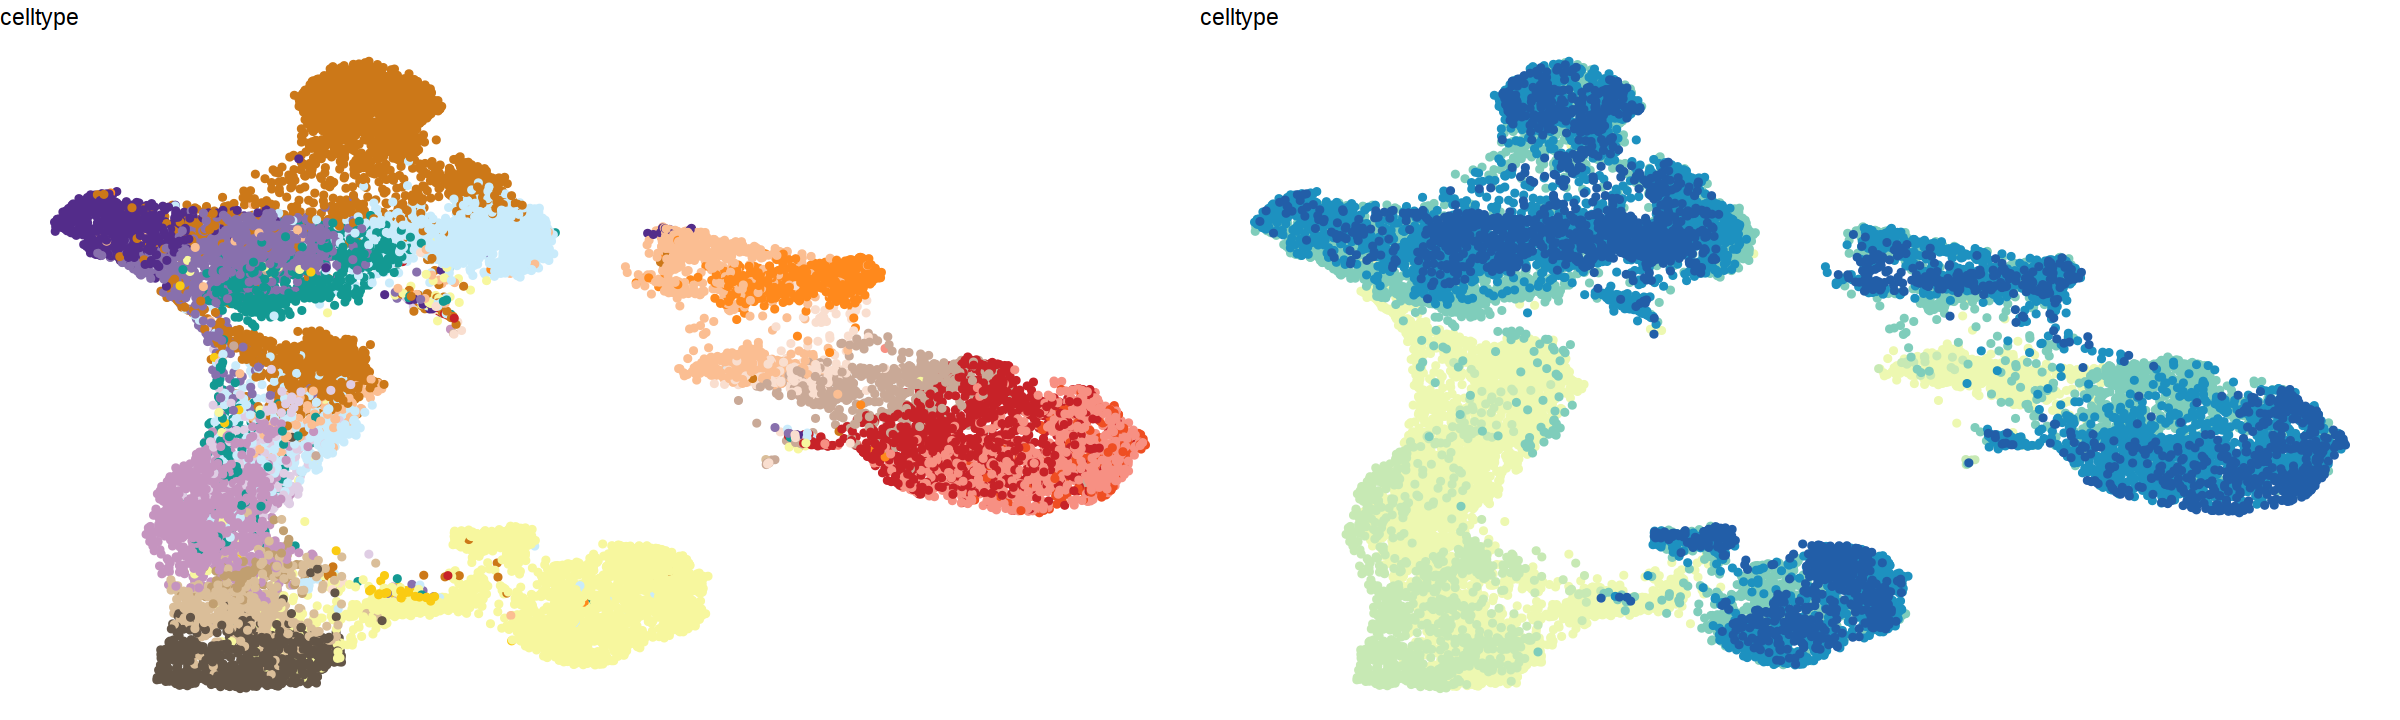

In [47]:
    umap.mtx = umap(LSI$matSVD[,1:args$ndims], 
                    n_neighbors = 30,
                    min_dist = 0.3)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        ggtitle('celltype') + 
        scale_colour_manual(values=opts$stage.colors) + 
        theme_void() + 
        theme(legend.position="none")
    
    options(repr.plot.width=20, repr.plot.height=6)
ggarrange(p1, p2)

List of length 13
names(13): matSVD rowSm nCol exclude idx ... LSIMethod outliers date seed

In [51]:
# clustering in Seurat
library(Seurat)

# Create object
seurat = CreateSeuratObject(
  counts = counts(sce))
# Add LSI
LSI = LSI$matSVD
seurat[['LSI']] = CreateDimReducObject(embeddings = LSI, key = "LSI_", assay = DefaultAssay(seurat))
# Find clusters
seurat <- FindNeighbors(seurat, dims = 1:args$ndims, reduction = 'LSI')
seurat <- FindClusters(seurat, resolution = 0.3, reduction = 'LSI')
clusters = seurat@meta.data$seurat_clusters

# Find variable features across clusters 
sce_pb = aggregateAcrossCells(sce, id=clusters, BPPARAM = BPPARAM, statistics='mean')
region_vars = rowVars(counts(sce_pb))
names(region_vars) = rownames(sce_pb)


## second round of LSI on top variable features

region_vars = region_vars[order(-region_vars)]
# get overlap of top 40k features
top = names(head(region_vars, args$ntop))

# LSI iteration 2
LSI = ArchR:::.computeLSI( mat = atac.counts[top,], 
  LSIMethod = 1,
  scaleTo = 10^4,
  nDimensions = args$ndims, 
  binarize = TRUE, 
  outlierQuantiles = c(0.02, 0.98),
  seed = 1234)

Computing nearest neighbor graph

Computing SNN

Warning message:
“The following arguments are not used: reduction”
Warning message:
“The following arguments are not used: reduction”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17986
Number of edges: 621765

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9389
Number of communities: 11
Elapsed time: 1 seconds


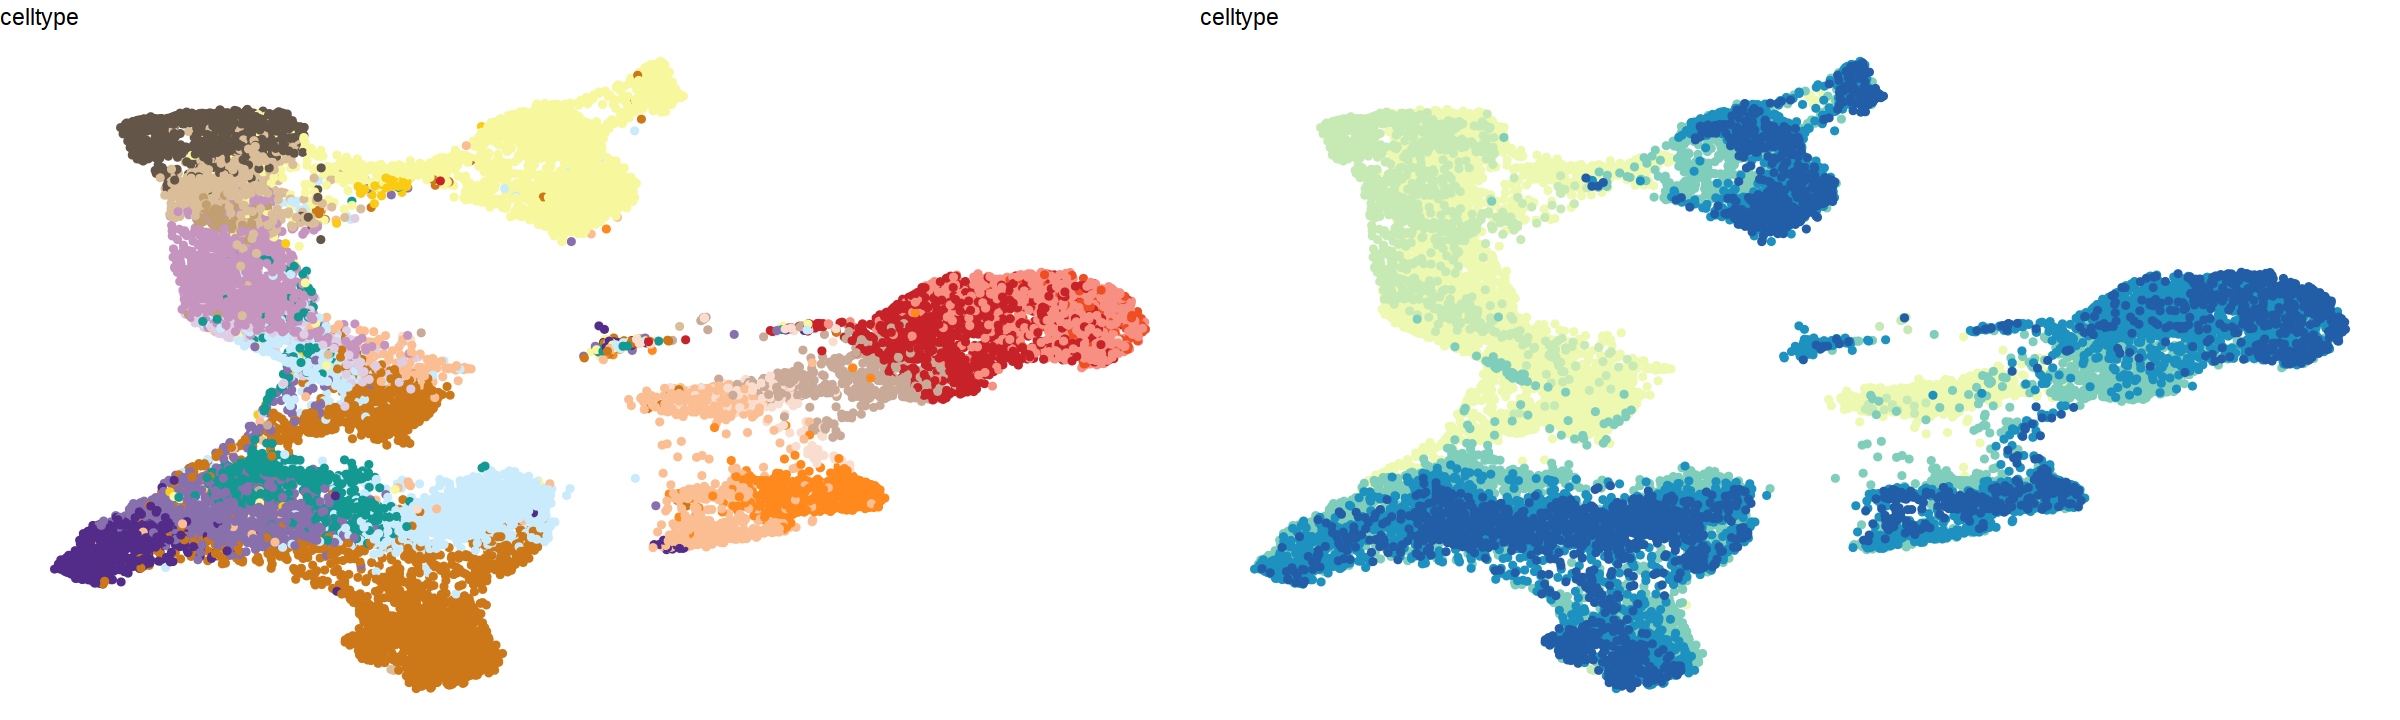

In [52]:
    umap.mtx = umap(LSI$matSVD[,1:args$ndims], 
                    n_neighbors = 30,
                    min_dist = 0.3)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'stage', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        ggtitle('celltype') + 
        scale_colour_manual(values=opts$stage.colors) + 
        theme_void() + 
        theme(legend.position="none")
    
    options(repr.plot.width=20, repr.plot.height=6)
ggarrange(p1, p2)